## Tackling Overfitting via Regularization

Overfitting is a common problem in machine learning where a model performs well on training data but does not generalize well to unseen data. This is fundamentally a struggle between **bias** and **variance**.

---

### 1. The Bias-Variance Tradeoff

* **Underfitting (High Bias):** The model is not complex enough to capture the underlying patterns in the training data (e.g., a linear boundary trying to separate non-linear data).
* **Overfitting (High Variance):** The model is too complex and captures the noise in the training data, leading to a failure in generalization.
* **Consistency:** Variance measures the consistency of a model's predictions if we were to retrain it multiple times on different subsets of the data.



---

### 2. L2 Regularization (Weight Decay)

Regularization introduces additional information to penalize extreme parameter (weight) values. The most common form is **L2 regularization** (also called L2 shrinkage or weight decay):

$$\frac{\lambda}{2n} \|w\|^2 = \frac{\lambda}{2n} \sum_{j=1}^{m} w_j^2$$

* **$\lambda$**: The regularization parameter used to control how closely we fit the training data vs. keeping weights small.
* **$n$**: The sample size, used to scale the term.
* **Note**: The bias unit ($b$) is typically not regularized.

#### Regularized Loss Function for Logistic Regression:
$$L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} \left[ -y^{(i)} \log(\sigma(z^{(i)})) - (1 - y^{(i)}) \log(1 - \sigma(z^{(i)})) \right] + \frac{\lambda}{2n} \|w\|^2$$

#### Impact on the Gradient:
The partial derivative of the loss function changes to include the regularization term:
$$\frac{\partial L(\mathbf{w}, b)}{\partial w_j} = \left( \frac{1}{n} \sum_{i=1}^{n} (\sigma(w^T x^{(i)}) - y^{(i)}) x_j^{(i)} \right) + \frac{\lambda}{n} w_j$$

---

### 3. The Inverse Regularization Parameter ($C$)

In `scikit-learn`, the `LogisticRegression` class uses the parameter **$C$** instead of $\lambda$. This convention comes from Support Vector Machines (SVM). $C$ is **inversely proportional** to the regularization strength:

$$C = \frac{1}{\lambda}$$

* **Decreasing $C$**: Increases regularization strength (shrinks weights closer to zero).
* **Increasing $C$**: Decreases regularization strength (allows weights to grow, fitting the data more closely).



> **Important:** For regularization to work properly, feature scaling (like **Standardization**) is essential. It ensures that all features are on a comparable scale so that the regularization penalty is applied fairly across all weights.

<p align="center">
  <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch03/figures/03_07.png" width="600">
</p>

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

### Fit logistic regression models with different values for C.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

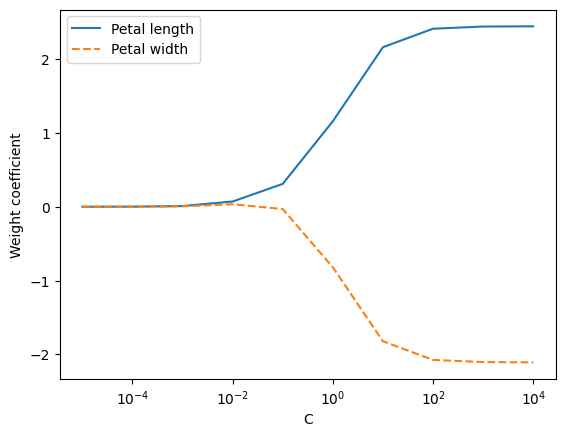

In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

weights, params = [], []
for c in np.arange(-5, 5):
    lr = LogisticRegression(C=10.**c,
                            multi_class='ovr')
    lr.fit(X_train_std, y_train)
    weights.append(lr.coef_[1])
    params.append(10.**c)

weights = np.array(weights)
plt.plot(params, weights[:, 0],
         label='Petal length')
plt.plot(params, weights[:, 1], linestyle='--',
         label='Petal width')
plt.ylabel('Weight coefficient')
plt.xlabel('C')
plt.legend(loc='upper left')
plt.xscale('log')
plt.show()